# Package Import

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Data Collection

## Read CSV

In [27]:
chili_df = pd.read_csv('dataset/cabai_rawit_combined.csv')

## Data Cleaning

In [28]:
chili_df['Date'] = pd.to_datetime(
    chili_df['Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

chili_df = chili_df.sort_values('Date').reset_index(drop=True)

In [29]:
chili_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604 entries, 0 to 1603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1604 non-null   datetime64[ns]
 1   Price   1542 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 25.2 KB


In [30]:
chili_df.shape

(1604, 2)

# Exploratory Data Analysis

## Descriptive Analysis

In [31]:
print(chili_df['Price'].describe())

count      1542.000000
mean      50881.963035
std       20397.562678
min       24077.000000
25%       34103.750000
50%       43879.500000
75%       65787.250000
max      114246.000000
Name: Price, dtype: float64


## Dispersion Analysis

In [32]:
std_price = chili_df['Price'].std()
var_price = chili_df['Price'].var()
min_price = chili_df['Price'].min()
max_price = chili_df['Price'].max()
range_price = max_price - min_price

print(f"Standard Deviation : {std_price:.2f}")
print(f"Variance           : {var_price:.2f}")
print(f"Min                : {min_price:.2f}")
print(f"Max                : {max_price:.2f}")
print(f"Range              : {range_price:.2f}")

Standard Deviation : 20397.56
Variance           : 416060563.19
Min                : 24077.00
Max                : 114246.00
Range              : 90169.00


## Outliers Analysis

In [33]:
Q1 = chili_df['Price'].quantile(0.25)
Q2 = chili_df['Price'].quantile(0.50)
Q3 = chili_df['Price'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 : {Q1:.2f}")
print(f"Q2 : {Q2:.2f}")
print(f"Q3 : {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

# Outlier bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"\nLower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")

Q1 : 34103.75
Q2 : 43879.50
Q3 : 65787.25
IQR: 31683.50

Lower Bound : -13421.50
Upper Bound : 113312.50


In [34]:
outliers = chili_df[
    (chili_df['Price'] < lower_bound) |
    (chili_df['Price'] > upper_bound)
]

print("Total Outliers:", len(outliers))

outlier_percentage = (
    len(outliers) / len(chili_df)
) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

print("\nSample Outliers:")
print(outliers.head())

Total Outliers: 1
Outlier Percentage: 0.06%

Sample Outliers:
           Date     Price
1157 2025-03-03  114246.0


In [35]:
outliers[['Date', 'Price']]

,Date,Price
1157,2025-03-03,114246.0


## Distribution Analysis

In [36]:
price_clean = chili_df['Price'].dropna()

skewness = skew(price_clean)
kurt = kurtosis(price_clean)

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurt:.4f}")

# Interpretation
if skewness > 0:
    print("Distribution: Right-Skewed")
elif skewness < 0:
    print("Distribution: Left-Skewed")
else:
    print("Distribution: Symmetric")

Skewness : 0.7737
Kurtosis : -0.3627
Distribution: Right-Skewed


## Histogram

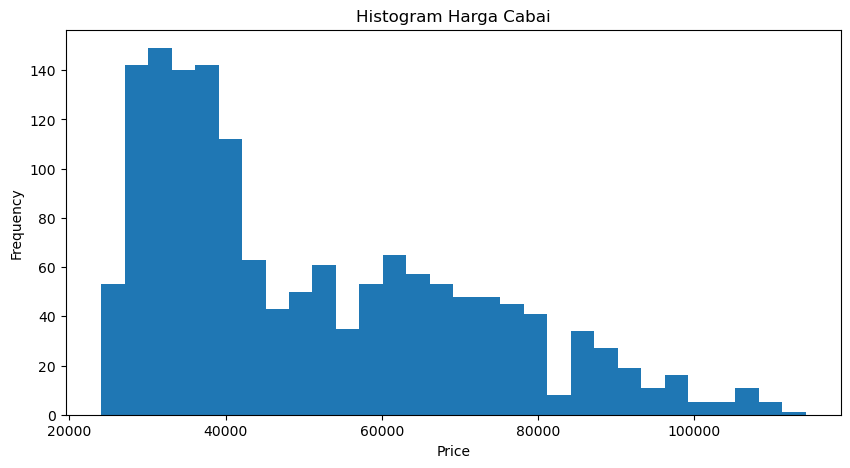

In [37]:
plt.figure(figsize=(10,5))

plt.hist(chili_df['Price'], bins=30)

plt.title("Histogram Harga Cabai")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

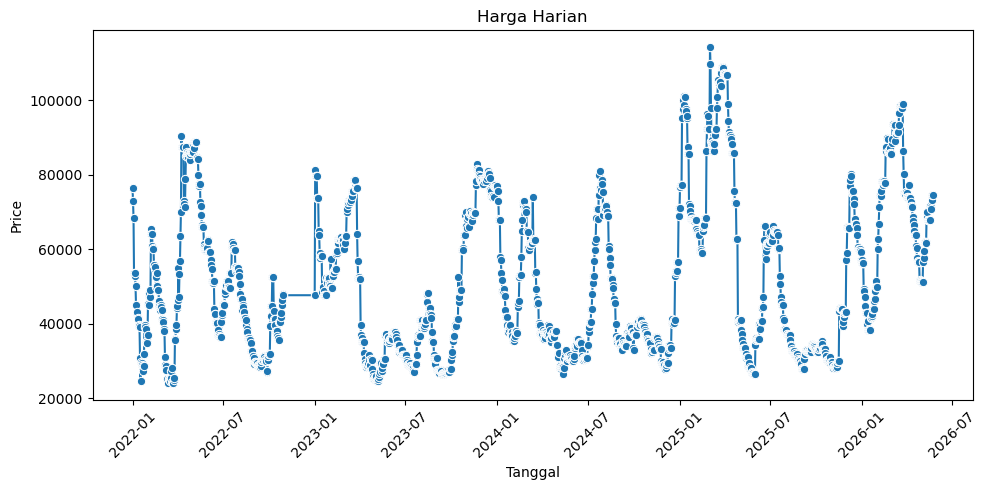

C:\Users\user\AppData\Local\Temp\ipykernel_11852\3269963137.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = chili_df.resample('M', on='Date').mean(numeric_only=True)


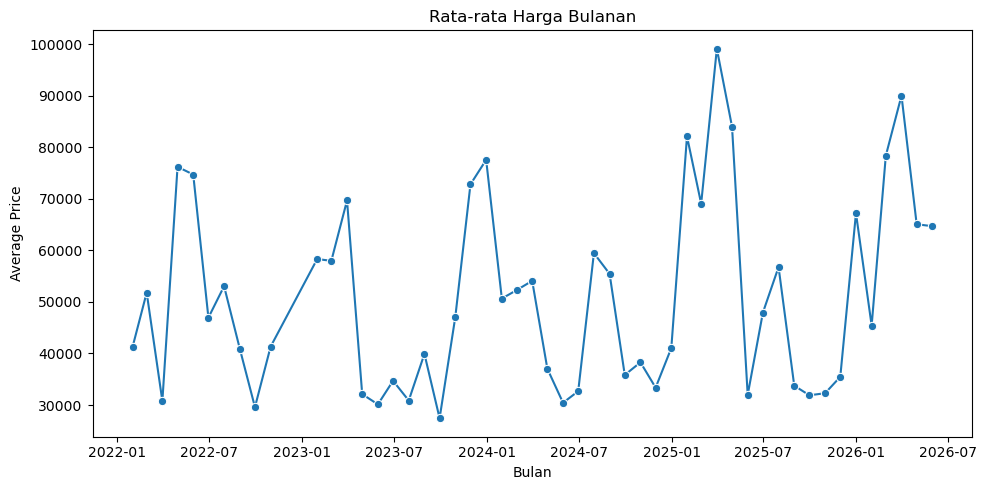

C:\Users\user\AppData\Local\Temp\ipykernel_11852\3269963137.py:36: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = chili_df.resample('Y', on='Date').mean(numeric_only=True)


ValueError: Could not interpret value `Price_Smooth` for `y`. An entry with this name does not appear in `data`.

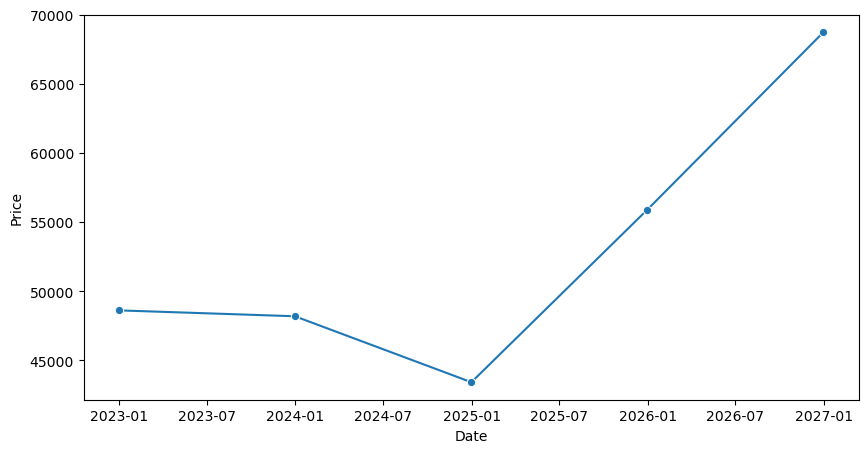

In [39]:
# Outlier Handling
# chili_df['Price_Smooth'] = chili_df['Price'].rolling(3).mean()

# =========================
# PLOT HARIAN
# =========================
plt.figure(figsize=(10,5))
sns.lineplot(data=chili_df, x='Date', y='Price', marker='o')

plt.title('Harga Harian')
plt.xlabel('Tanggal')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE BULANAN
# =========================
monthly = chili_df.resample('M', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x=monthly.index, y='Price', marker='o')

plt.title('Rata-rata Harga Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE TAHUNAN
# =========================
yearly = chili_df.resample('Y', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x=yearly.index, y='Price', marker='o')
sns.lineplot(data=yearly, x=yearly.index, y='Price_Smooth', marker='s')

plt.title('Rata-rata Harga Tahunan')
plt.xlabel('Tahun')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

In [ ]:
# AMBIL TAHUN DAN BULAN
chili_df['Year'] = chili_df['Date'].dt.year
chili_df['Month'] = chili_df['Date'].dt.strftime('%b')

print(chili_df)

# =========================
# VISUALIZATION
# =========================
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=chili_df,
    x='Month',
    y='Price',
    hue='Year',
    marker='o'
)

plt.title('Perbandingan Harga Antar Tahun')
plt.xlabel('Bulan')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

## Data Preprocessing

### NULL Value Handling

In [ ]:
chili_df['Price'] = chili_df['Price'].interpolate(method='linear')

### Feature Engineering

In [40]:
chili_df['Year'] = chili_df['Date'].dt.year
chili_df['Month'] = chili_df['Date'].dt.month
chili_df['Day'] = chili_df['Date'].dt.day

chili_df['DayOfWeek'] = chili_df['Date'].dt.dayofweek
chili_df['WeekOfYear'] = chili_df['Date'].dt.isocalendar().week.astype(int)

### Lag Features

In [41]:
lags = [1,2,3,7,14,21,30]

for lag in lags:
    chili_df[f'lag_{lag}'] = chili_df['Price'].shift(lag)

### Rolling Statistics

In [42]:
# Rolling Statistics
chili_df['rolling_mean_3'] = chili_df['Price'].shift(1).rolling(3).mean()
chili_df['rolling_mean_7'] = chili_df['Price'].shift(1).rolling(7).mean()
chili_df['rolling_mean_14'] = chili_df['Price'].shift(1).rolling(14).mean()

chili_df['rolling_max_7'] = chili_df['Price'].shift(1).rolling(7).max()
chili_df['rolling_min_7'] = chili_df['Price'].shift(1).rolling(7).min()
chili_df['rolling_std_7'] = chili_df['Price'].shift(1).rolling(7).std()

In [43]:
# Cyclic Features
chili_df['month_sin'] = np.sin(2 * np.pi * chili_df['Month']/12)
chili_df['month_cos'] = np.cos(2 * np.pi * chili_df['Month']/12)

# Feature Momentum
chili_df['diff_1'] = chili_df['Price'].diff(1)
chili_df['diff_7'] = chili_df['Price'].diff(7)

chili_df['pct_change_7'] = chili_df['Price'].pct_change(7)

# Log Transformation
chili_df['Price_log'] = np.log(chili_df['Price'] + 1)

C:\Users\user\AppData\Local\Temp\ipykernel_11852\616688731.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  chili_df['pct_change_7'] = chili_df['Price'].pct_change(7)


In [44]:
chili_df = chili_df.dropna()

print(chili_df.head())

         Date    Price  Year  Month  Day  DayOfWeek  WeekOfYear    lag_1  \
30 2022-01-31  36875.0  2022      1   31          0           5  34800.0   
31 2022-02-01  45154.0  2022      2    1          1           5  36875.0   
32 2022-02-02  47462.0  2022      2    2          2           5  45154.0   
33 2022-02-03  48167.0  2022      2    3          3           5  47462.0   
34 2022-02-04  44885.0  2022      2    4          4           5  48167.0   

      lag_2    lag_3  ...  rolling_mean_14  rolling_max_7  rolling_min_7  \
30  35357.0  35000.0  ...     32225.214286        39583.0        31929.0   
31  34800.0  35357.0  ...     33097.214286        39583.0        34800.0   
32  36875.0  34800.0  ...     34205.142857        45154.0        34800.0   
33  45154.0  36875.0  ...     35497.857143        47462.0        34800.0   
34  47462.0  45154.0  ...     36866.928571        48167.0        34800.0   

    rolling_std_7  month_sin  month_cos  diff_1  diff_7  pct_change_7  \
30    2794.10

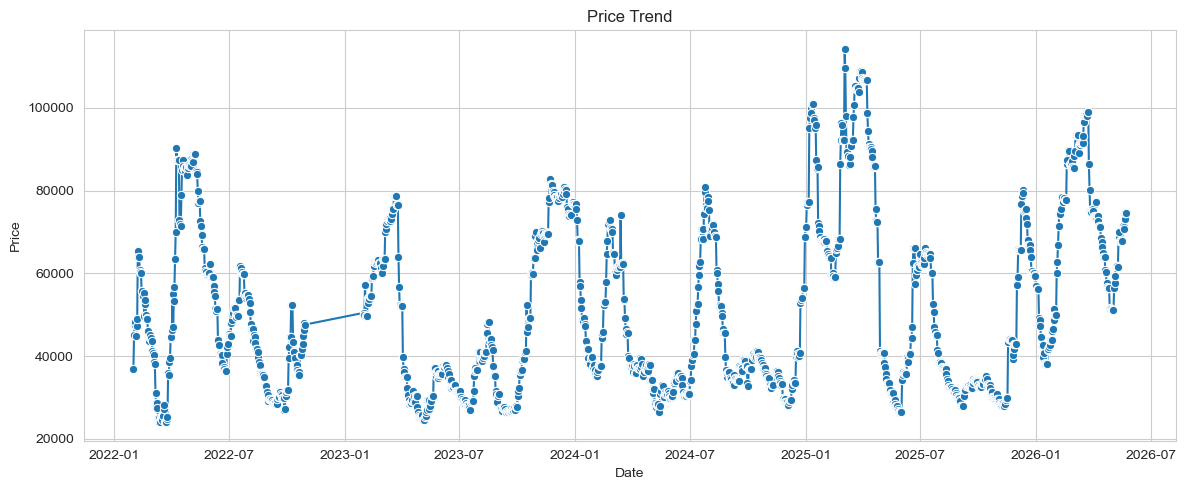

In [45]:
sns.set_style('whitegrid')

plt.figure(figsize=(12,5))

sns.lineplot(data=chili_df, x='Date', y='Price', marker='o')

plt.title('Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Model Training

In [46]:
train = chili_df[chili_df['Date'] < '2026-01-01']
test = chili_df[chili_df['Date'] >= '2026-01-01']

In [47]:
features = features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',

    'rolling_mean_3',
    'rolling_mean_7',
    'rolling_mean_14',

    'rolling_std_7',

    'diff_1',
    'diff_7',

    'pct_change_7',

    'month_sin',
    'month_cos',

    'DayOfWeek'
]

## Modeling

In [48]:
tscv = TimeSeriesSplit(n_splits=5)

scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(chili_df)):
    train_fold = chili_df.iloc[train_idx]
    val_fold = chili_df.iloc[val_idx]

    X_train = train_fold[features]
    y_train = train_fold['Price']
    X_val = val_fold[features]
    y_val = val_fold['Price']

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    scores.append({
        'fold': fold + 1,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': root_mean_squared_error(y_val, pred),
        'MAPE': np.mean(np.abs((y_val - pred) / y_val)) * 100
    })

pd.DataFrame(scores)

,fold,MAE,RMSE,MAPE
0,1,1401.101143,2829.610179,2.767424
1,2,1154.525984,1807.432417,1.977182
2,3,913.998814,2539.695961,1.507601
3,4,1878.833439,4070.736308,2.192852
4,5,567.629310,994.741265,0.931862
